### Description

This notebook is to demonstarte the $\Delta \chi^2$ difference between $\textit{CoCoA}$ anc $\textit{CCL}$ under specific setups


### First load covariance matrix as it is reusable and computational expensive

In [1]:
#load covariance matrix and dv from cosmolike
import numpy as np
import pytest
import pyccl as ccl
from pyccl import CCLWarning

from pyccl.pk2d import Pk2D
from pyccl.correlations import correlation, correlation_binned

import os
os.environ["OMP_NUM_THREADS"] = "12"


cov_file = './cocoa/Cocoa/projects/roman_real/data/cov_roman'
mask_file = './cocoa/Cocoa/projects/roman_real/data/roman_Y3.mask'
mask = np.loadtxt(mask_file)[:,1].astype(bool)
cov_raw = np.loadtxt(cov_file)
ncov = int(np.max(cov_raw[:,0]))+1
cov = np.zeros((ncov, ncov))
for i in range(len(cov_raw)):
    ii = int(cov_raw[i, 0])
    jj = int(cov_raw[i, 1])
    element = cov_raw[i,8] + cov_raw[i,9]
    cov[ii,jj] = element
    cov[jj,ii] = element

### COMPARE SETUP0

In [6]:
#------------------INPUT------------------------------------------------------#
SETUP = 'setup0'
#-----------------------------------------------------------------------------#
#---------YOU STILL NEED TO MODIFY THE CCL'S MODELLING BELOW------------------#
#-----------------------------------------------------------------------------#

# ccl.gsl_params.LENSING_KERNEL_SPLINE_INTEGRATION = False
# setup cosmology
COSMO = ccl.Cosmology(
    Omega_c=0.26507647072945384,
    Omega_b=0.0495,
    Omega_k=0,
    h=0.6732,
    w0=-1,
    wa=0,
    A_s=2.1/1e9,
    n_s=0.96605,
    m_nu=0.06,
    Neff=3.046,
    mass_split='single',
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',
    extra_parameters = {"camb": {"halofit_version": "takahashi",
                                 'AccuracyBoost': 1.0,
                                 'kmax':15,
                                 'dark_energy_model': 'ppf',
                                 'accurate_massive_neutrino_transfer': False,
                                 'k_per_logint': 15,
                                 }}
    )
h=0.6732

#-----------------------------------------------------------------#
#---------------based on discussion in section 0------------------#
#------------------we use this power spectrum---------------------#
#-----------------------------------------------------------------# 

filepath = f'./cocoa/Cocoa/projects/roman_real/chains/roman_{SETUP}_evaluate/'
z_pk_cocoa = np.loadtxt(filepath+'z_pk_1.txt')
k_pk_cocoa = np.loadtxt(filepath+'k_pk_1.txt')   #1/Mpc
lnPk_cocoa = np.loadtxt(filepath+'pknl_1.txt').reshape(len(k_pk_cocoa),len(z_pk_cocoa) ).T   #Mpc/h^3
lnPk_lin_cocoa = np.loadtxt(filepath+'pkln_1.txt').reshape(len(k_pk_cocoa),len(z_pk_cocoa) ).T   #Mpc/h^3
lnPk_cocoa = lnPk_cocoa[::-1,:] - 3*np.log(h)
lnPk_lin_cocoa = lnPk_lin_cocoa[::-1,:] - 3*np.log(h)
a_pk_cocoa = 1/(1+z_pk_cocoa)[::-1]
lnk_pk_cocoa = np.log(k_pk_cocoa)

pk2_cocoa = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=lnPk_cocoa, is_logp=True)
pk2_lin_cocoa = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=lnPk_lin_cocoa, is_logp=True)
pk2_ccl     = COSMO.nonlin_matter_power(k = np.exp(lnk_pk_cocoa), a = a_pk_cocoa)
pk2_lin_ccl = COSMO.linear_matter_power(k = np.exp(lnk_pk_cocoa), a = a_pk_cocoa)
pk2_ccl     = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=np.log(pk2_ccl), is_logp=True)
pk2_lin_ccl = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=np.log(pk2_lin_ccl), is_logp=True)

#---------------------------------------------------------------------------------------------#
#-------------------this Pk is further injected into power specetrum calculation--------------#
#---------------------------------------------------------------------------------------------#


#set up lens source sample
srcs_nzs = np.loadtxt('./cocoa/Cocoa/projects/roman_real/data/fiducial.nz')
lens_nzs = np.loadtxt('./cocoa/Cocoa/projects/roman_real/data/lsst_lens_4cosmolike.nz')

z_srcs = srcs_nzs[:,0]+0.005
srcs_nz = srcs_nzs[:,1:]
z_lens = lens_nzs[:,0]+0.005
lens_nz = lens_nzs[:,1:]

srcs = []
lens = []
nsrcs = 8
nlens = 10
gbias =  [1.09,1.15,1.21,1.27,1.33,1.40,1.46,1.53,1.60,1.67]
ggl_exclude = []

for i in range(nsrcs):
    srcs.append(ccl.WeakLensingTracer(COSMO, dndz=(z_srcs, srcs_nz[:,i]), has_shear=True, n_samples=400))
for i in range(nlens):
    lens.append(ccl.NumberCountsTracer(COSMO, dndz=(z_lens, lens_nz[:,i]), bias=(z_lens,np.ones_like(z_lens)*gbias[i]), has_rsd=False, n_samples=400))


#calculate the power spectrum for calculation of correlation function
logLMIN = np.log(20)
logLMAX = np.log(60000+1)
NCell = 300
dlogL = (logLMAX - logLMIN)/(NCell - 1)

ells = np.zeros(20+NCell)
for i in range(20):
    ells[i] = i
for i in range(NCell):
    ells[i+20] = np.exp(logLMIN + dlogL*i)
ells = ells[1:]

corrs = []
for i in range(nsrcs):
    for j in range(i,nsrcs):
        corrs.append(ccl.angular_cl(COSMO, srcs[i], srcs[j], ells, p_of_k_a=pk2_cocoa, l_limber=-1) )

for i in range(nlens):
    for j in range(nsrcs):
        if [i,j] in ggl_exclude:
            continue
        corrs.append(ccl.angular_cl(COSMO, lens[i], srcs[j], ells, p_of_k_a=pk2_cocoa, l_limber=-1) )
        
for i in range(nlens):
    corrs.append(ccl.angular_cl(COSMO, lens[i], lens[i], ells, p_of_k_a=pk2_cocoa,l_limber=-1))    
#calculate the correlation function
tmin = 1.
tmax = 500.
ntheta = 20

logtmin = np.log(tmin)
logtmax = np.log(tmax)
logdt=(logtmax - logtmin)/ntheta
fac = (2./3.)
thetas = np.zeros(ntheta)

for i in range(ntheta):
    thetamin = np.exp(logtmin + (i + 0.)*logdt)
    thetamax = np.exp(logtmin + (i + 1.)*logdt)
    thetas[i] = fac * (thetamax**3 - thetamin**3) / (thetamax*thetamax    - thetamin*thetamin)
thetas /= 60

theta_b  = np.geomspace(tmin, tmax, ntheta+1) / 60
theta_u  = theta_b[1:]
theta_l  = theta_b[:-1]

ncombo1 = int(nsrcs*(nsrcs+1)/2)
ncombo2 = int(nsrcs*nlens)
ncombo3 = int(nlens)

xip, xim, gammat, wtheta = [],[],[],[]
for i in range(ncombo1):
    xip.append(correlation(COSMO, ell=ells, C_ell=corrs[i], theta=thetas, type='GG+', method='Legendre'))
    xim.append(correlation(COSMO, ell=ells, C_ell=corrs[i], theta=thetas, type='GG-', method='Legendre'))
xip = np.concatenate(xip)
xim = np.concatenate(xim)

for i in range(ncombo1, ncombo1+ncombo2):
    gammat.append(correlation(COSMO, ell=ells, C_ell=corrs[i], theta=thetas, type='NG', method='Legendre'))
gammat = np.concatenate(gammat)

for i in range(ncombo1 + ncombo2, ncombo1 + ncombo2 + ncombo3):
    wtheta.append(correlation(COSMO, ell=ells, C_ell=corrs[i], theta=thetas, type='NN', method='Legendre'))
wtheta = np.concatenate(wtheta)
 
dv_ccl = np.concatenate((xip,xim,gammat,wtheta))


#------------------------------------------------------------------------------------------------------------
import importlib
import utils
importlib.reload(utils)

dv_cosmolike = np.loadtxt(f'./cocoa/Cocoa/projects/roman_real/chains/roman_{SETUP}_evaluate/roman.modelvector_1')[:,1]

utils.compare(
    dv_ccl,
    dv_cosmolike,
    cov,
    mask,
    'ccl',
    'cosmolike',
    'real',
    10,
    8,
    1,
    500,
    20,
    [ True, True, True],
    [ True, True, True],
    [ True, True, True],
    True,
    True,
    True,
    False,
)

xi chi2 is 0.008/0.039
gammat chi2 is 0.007/0.055
wtheta chi2 is 0.001/0.014
3x2pt chi2 is 0.015/0.048


### COMPARE SETUP1

In [2]:
#------------------INPUT------------------------------------------------------#
SETUP = 'setup1'
#-----------------------------------------------------------------------------#
#---------YOU STILL NEED TO MODIFY THE CCL'S MODELLING BELOW------------------#
#-----------------------------------------------------------------------------#

# ccl.gsl_params.LENSING_KERNEL_SPLINE_INTEGRATION = False
# setup cosmology
COSMO = ccl.Cosmology(
    Omega_c=0.26507647072945384,
    Omega_b=0.0495,
    Omega_k=0,
    h=0.6732,
    w0=-1,
    wa=0,
    A_s=2.1/1e9,
    n_s=0.96605,
    m_nu=0.06,
    Neff=3.046,
    mass_split='single',
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',
    extra_parameters = {"camb": {"halofit_version": "takahashi",
                                 'AccuracyBoost': 1.0,
                                 'kmax':15,
                                 'dark_energy_model': 'ppf',
                                 'accurate_massive_neutrino_transfer': False,
                                 'k_per_logint': 15,
                                 }}
    )
h=0.6732

#-----------------------------------------------------------------#
#---------------based on discussion in section 0------------------#
#------------------we use this power spectrum---------------------#
#-----------------------------------------------------------------# 

filepath = f'./cocoa/Cocoa/projects/roman_real/chains/roman_{SETUP}_evaluate/'
z_pk_cocoa = np.loadtxt(filepath+'z_pk_1.txt')
k_pk_cocoa = np.loadtxt(filepath+'k_pk_1.txt')   #1/Mpc
lnPk_cocoa = np.loadtxt(filepath+'pknl_1.txt').reshape(len(k_pk_cocoa),len(z_pk_cocoa) ).T   #Mpc/h^3
lnPk_lin_cocoa = np.loadtxt(filepath+'pkln_1.txt').reshape(len(k_pk_cocoa),len(z_pk_cocoa) ).T   #Mpc/h^3
lnPk_cocoa = lnPk_cocoa[::-1,:] - 3*np.log(h)
lnPk_lin_cocoa = lnPk_lin_cocoa[::-1,:] - 3*np.log(h)
a_pk_cocoa = 1/(1+z_pk_cocoa)[::-1]
lnk_pk_cocoa = np.log(k_pk_cocoa)

pk2_cocoa = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=lnPk_cocoa, is_logp=True)
pk2_lin_cocoa = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=lnPk_lin_cocoa, is_logp=True)
pk2_ccl     = COSMO.nonlin_matter_power(k = np.exp(lnk_pk_cocoa), a = a_pk_cocoa)
pk2_lin_ccl = COSMO.linear_matter_power(k = np.exp(lnk_pk_cocoa), a = a_pk_cocoa)
pk2_ccl     = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=np.log(pk2_ccl), is_logp=True)
pk2_lin_ccl = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=np.log(pk2_lin_ccl), is_logp=True)

#---------------------------------------------------------------------------------------------#
#-------------------this Pk is further injected into power specetrum calculation--------------#
#---------------------------------------------------------------------------------------------#


#set up lens source sample
srcs_nzs = np.loadtxt('./cocoa/Cocoa/projects/roman_real/data/fiducial.nz')
lens_nzs = np.loadtxt('./cocoa/Cocoa/projects/roman_real/data/lsst_lens_4cosmolike.nz')

z_srcs = srcs_nzs[:,0]+0.005
srcs_nz = srcs_nzs[:,1:]
z_lens = lens_nzs[:,0]+0.005
lens_nz = lens_nzs[:,1:]

srcs = []
lens = []
nsrcs = 8
nlens = 10
gbias =  [1.09,1.15,1.21,1.27,1.33,1.40,1.46,1.53,1.60,1.67]
ggl_exclude = []

for i in range(nsrcs):
    srcs.append(ccl.WeakLensingTracer(COSMO, dndz=(z_srcs, srcs_nz[:,i]), has_shear=True, n_samples=400))
for i in range(nlens):
    lens.append(ccl.NumberCountsTracer(COSMO, dndz=(z_lens, lens_nz[:,i]), bias=(z_lens,np.ones_like(z_lens)*gbias[i]), has_rsd=False, n_samples=400))


#calculate the power spectrum for calculation of correlation function
logLMIN = np.log(20)
logLMAX = np.log(60000+1)
NCell = 300
dlogL = (logLMAX - logLMIN)/(NCell - 1)

ells = np.zeros(20+NCell)
for i in range(20):
    ells[i] = i
for i in range(NCell):
    ells[i+20] = np.exp(logLMIN + dlogL*i)
ells = ells[1:]

corrs = []
for i in range(nsrcs):
    for j in range(i,nsrcs):
        corrs.append(ccl.angular_cl(COSMO, srcs[i], srcs[j], ells, p_of_k_a=pk2_cocoa, l_limber=-1) )

for i in range(nlens):
    for j in range(nsrcs):
        if [i,j] in ggl_exclude:
            continue
        corrs.append(ccl.angular_cl(COSMO, lens[i], srcs[j], ells, p_of_k_a=pk2_cocoa, l_limber=-1) )
        
for i in range(nlens):
    corrs.append(ccl.angular_cl(COSMO, lens[i], lens[i], ells, p_of_k_a=pk2_cocoa,l_limber=-1))    
#calculate the correlation function
tmin = 1.
tmax = 500.
ntheta = 20

logtmin = np.log(tmin)
logtmax = np.log(tmax)
logdt=(logtmax - logtmin)/ntheta
fac = (2./3.)
thetas = np.zeros(ntheta)

for i in range(ntheta):
    thetamin = np.exp(logtmin + (i + 0.)*logdt)
    thetamax = np.exp(logtmin + (i + 1.)*logdt)
    thetas[i] = fac * (thetamax**3 - thetamin**3) / (thetamax*thetamax    - thetamin*thetamin)
thetas /= 60

theta_b  = np.geomspace(tmin, tmax, ntheta+1) / 60
theta_u  = theta_b[1:]
theta_l  = theta_b[:-1]

ncombo1 = int(nsrcs*(nsrcs+1)/2)
ncombo2 = int(nsrcs*nlens)
ncombo3 = int(nlens)

xip, xim, gammat, wtheta = [],[],[],[]
for i in range(ncombo1):
    xip.append(correlation_binned(COSMO, ell=ells, C_ell=corrs[i], theta_min=theta_l, theta_max=theta_u, type='GG+', method='Legendre'))
    xim.append(correlation_binned(COSMO, ell=ells, C_ell=corrs[i], theta_min=theta_l, theta_max=theta_u, type='GG-', method='Legendre'))
xip = np.concatenate(xip)
xim = np.concatenate(xim)

for i in range(ncombo1, ncombo1+ncombo2):
    gammat.append(correlation_binned(COSMO, ell=ells, C_ell=corrs[i], theta_min=theta_l, theta_max=theta_u, type='NG', method='Legendre'))
gammat = np.concatenate(gammat)

for i in range(ncombo1 + ncombo2, ncombo1 + ncombo2 + ncombo3):
    wtheta.append(correlation_binned(COSMO, ell=ells, C_ell=corrs[i], theta_min=theta_l, theta_max=theta_u, type='NN', method='Legendre'))
wtheta = np.concatenate(wtheta)
 
dv_ccl = np.concatenate((xip,xim,gammat,wtheta))


#------------------------------------------------------------------------------------------------------------
import importlib
import utils
importlib.reload(utils)

dv_cosmolike = np.loadtxt(f'./cocoa/Cocoa/projects/roman_real/chains/roman_{SETUP}_evaluate/roman.modelvector_1')[:,1]

utils.compare(
    dv_ccl,
    dv_cosmolike,
    cov,
    mask,
    'ccl',
    'cosmolike',
    'real',
    10,
    8,
    1,
    500,
    20,
    [ True, True, True],
    [ True, True, True],
    [ True, True, True],
    True,
    True,
    True,
    False,
)

xi chi2 is 0.004/0.034
gammat chi2 is 0.007/0.055
wtheta chi2 is 0.000/0.013
3x2pt chi2 is 0.009/0.044


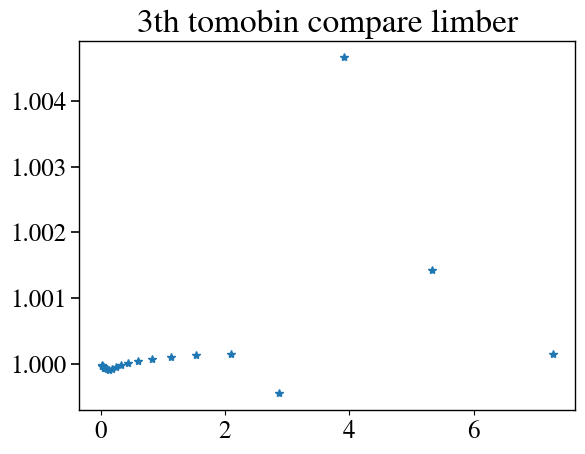

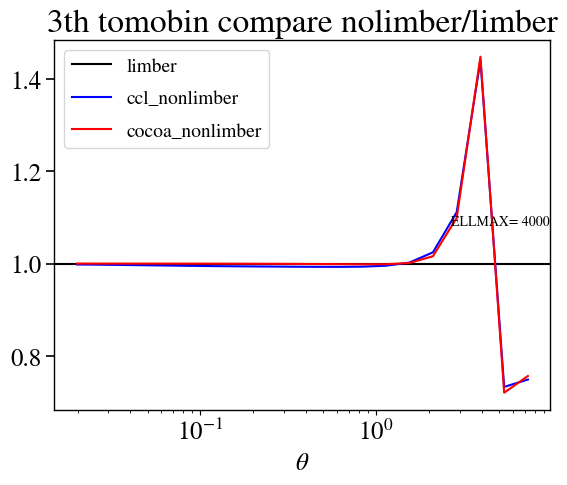

In [16]:
import matplotlib.pyplot as plt
nlens = 10
nsrcs = 8
nbins = 20
ggl_exclude = []
ELLMAX = 4000
wtheta_start = int( (nsrcs*(nsrcs+1) + nsrcs*nlens - len(ggl_exclude))*nbins )
i = 3
#---------------define ell grid--------------------------------------#
logLMIN = np.log(ELLMAX)
logLMAX = np.log(60000+1)
NCell = 300
dlogL = (logLMAX - logLMIN)/(NCell - 1)

ells = np.zeros(ELLMAX+NCell)
for j in range(ELLMAX):
    ells[j] = j
for j in range(NCell):
    ells[j+ELLMAX] = np.exp(logLMIN + dlogL*j)
ells = ells[1:]
#--------------------------------------------------------------------#

ccl_wtheta_nolimber = ccl.angular_cl(COSMO, lens[i], lens[i], ells, p_of_k_a=pk2_cocoa, l_limber=ELLMAX,
                                    limber_max_error=0.001,
                                    non_limber_integration_method='FKEM',
                                    fkem_chi_min = None,
                                    fkem_Nchi = 5000,
                                    p_of_k_a_lin = pk2_lin_cocoa,)
ccl_wtheta_nolimber = correlation_binned(COSMO, ell=ells, C_ell=ccl_wtheta_nolimber, theta_min=theta_l, theta_max=theta_u, type='NN', method='Legendre')
ccl_wtheta_limber = ccl.angular_cl(COSMO, lens[i], lens[i], ells, p_of_k_a=pk2_cocoa, l_limber=-1)
ccl_wtheta_limber = correlation_binned(COSMO, ell=ells, C_ell=ccl_wtheta_limber, theta_min=theta_l, theta_max=theta_u, type='NN', method='Legendre')

cocoa_wtheta_nolimber = np.loadtxt(f'./cocoa/Cocoa/projects/roman_real/chains/roman_nonlimber_evaluate/roman.modelvector_1')[:,1][wtheta_start + i*nbins:wtheta_start + i*nbins + nbins]
cocoa_wtheta_limber = np.loadtxt(f'./cocoa/Cocoa/projects/roman_real/chains/roman_limber_evaluate/roman.modelvector_1')[:,1][wtheta_start + i*nbins:wtheta_start + i*nbins + nbins]


plt.plot(thetas, ccl_wtheta_limber/cocoa_wtheta_limber, '*')
plt.title(f'{i}th tomobin compare limber')
plt.show()

plt.axhline(y = 1, xmin = 0, xmax = 1, c = 'k', label = 'limber')
plt.plot(thetas, ccl_wtheta_nolimber/ccl_wtheta_limber, 'b', label = 'ccl_nonlimber')
plt.plot(thetas, cocoa_wtheta_nolimber/ccl_wtheta_limber, 'r', label = 'cocoa_nonlimber')
plt.xlabel(r'$\theta$')
plt.text(x = 0.8, y = 0.5, s = f'ELLMAX= {ELLMAX} ', transform = plt.gca().transAxes)
plt.xscale('log')
plt.title(f'{i}th tomobin compare nolimber/limber')
plt.legend()
plt.show()

### COMPARE SETUP2

In [4]:
#------------------INPUT------------------------------------------------------#
SETUP = 'setup2'
binned = True
#-----------------------------------------------------------------------------#
#---------YOU STILL NEED TO MODIFY THE CCL'S MODELLING BELOW------------------#
#-----------------------------------------------------------------------------#

# ccl.gsl_params.LENSING_KERNEL_SPLINE_INTEGRATION = False
# setup cosmology
COSMO = ccl.Cosmology(
    Omega_c=0.26507647072945384,
    Omega_b=0.0495,
    Omega_k=0,
    h=0.6732,
    w0=-1,
    wa=0,
    A_s=2.1/1e9,
    n_s=0.96605,
    m_nu=0.06,
    Neff=3.046,
    mass_split='single',
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',
    extra_parameters = {"camb": {"halofit_version": "takahashi",
                                 'AccuracyBoost': 1.0,
                                 'kmax':15,
                                 'dark_energy_model': 'ppf',
                                 'accurate_massive_neutrino_transfer': False,
                                 'k_per_logint': 15,
                                 }}
    )
h=0.6732

#-----------------------------------------------------------------#
#---------------based on discussion in section 0------------------#
#------------------we use this power spectrum---------------------#
#-----------------------------------------------------------------# 

filepath = f'./cocoa/Cocoa/projects/roman_real/chains/roman_{SETUP}_evaluate/'
z_pk_cocoa = np.loadtxt(filepath+'z_pk_1.txt')
k_pk_cocoa = np.loadtxt(filepath+'k_pk_1.txt')   #1/Mpc
lnPk_cocoa = np.loadtxt(filepath+'pknl_1.txt').reshape(len(k_pk_cocoa),len(z_pk_cocoa) ).T   #Mpc/h^3
lnPk_lin_cocoa = np.loadtxt(filepath+'pkln_1.txt').reshape(len(k_pk_cocoa),len(z_pk_cocoa) ).T   #Mpc/h^3
lnPk_cocoa = lnPk_cocoa[::-1,:] - 3*np.log(h)
lnPk_lin_cocoa = lnPk_lin_cocoa[::-1,:] - 3*np.log(h)
a_pk_cocoa = 1/(1+z_pk_cocoa)[::-1]
lnk_pk_cocoa = np.log(k_pk_cocoa)

pk2_cocoa = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=lnPk_cocoa, is_logp=True)
pk2_lin_cocoa = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=lnPk_lin_cocoa, is_logp=True)
pk2_ccl     = COSMO.nonlin_matter_power(k = np.exp(lnk_pk_cocoa), a = a_pk_cocoa)
pk2_lin_ccl = COSMO.linear_matter_power(k = np.exp(lnk_pk_cocoa), a = a_pk_cocoa)
pk2_ccl     = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=np.log(pk2_ccl), is_logp=True)
pk2_lin_ccl = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=np.log(pk2_lin_ccl), is_logp=True)

#---------------------------------------------------------------------------------------------#
#-------------------this Pk is further injected into power specetrum calculation--------------#
#---------------------------------------------------------------------------------------------#


#set up lens source sample
srcs_nzs = np.loadtxt('./cocoa/Cocoa/projects/roman_real/data/fiducial.nz')
lens_nzs = np.loadtxt('./cocoa/Cocoa/projects/roman_real/data/lsst_lens_4cosmolike.nz')

z_srcs = srcs_nzs[:,0]+0.005
srcs_nz = srcs_nzs[:,1:]
z_lens = lens_nzs[:,0]+0.005
lens_nz = lens_nzs[:,1:]

srcs = []
lens = []
nsrcs = 8
nlens = 10
gbias =  [1.09,1.15,1.21,1.27,1.33,1.40,1.46,1.53,1.60,1.67]
ggl_exclude = []

for i in range(nsrcs):
    srcs.append(ccl.WeakLensingTracer(COSMO, dndz=(z_srcs, srcs_nz[:,i]), has_shear=True, n_samples=400))
for i in range(nlens):
    lens.append(ccl.NumberCountsTracer(COSMO, dndz=(z_lens, lens_nz[:,i]), bias=(z_lens,np.ones_like(z_lens)*gbias[i]), has_rsd=False, n_samples=400))


#calculate the power spectrum for calculation of correlation function
logLMIN = np.log(20)
logLMAX = np.log(60000+1)
NCell = 300
dlogL = (logLMAX - logLMIN)/(NCell - 1)

ells = np.zeros(20+NCell)
for i in range(20):
    ells[i] = i
for i in range(NCell):
    ells[i+20] = np.exp(logLMIN + dlogL*i)
ells = ells[1:]

corrs = []
for i in range(nsrcs):
    for j in range(i,nsrcs):
        corrs.append(ccl.angular_cl(COSMO, srcs[i], srcs[j], ells, p_of_k_a=pk2_cocoa, l_limber=-1) )

for i in range(nlens):
    for j in range(nsrcs):
        if [i,j] in ggl_exclude:
            continue
        corrs.append(ccl.angular_cl(COSMO, lens[i], srcs[j], ells, p_of_k_a=pk2_cocoa, l_limber=-1) )
        
for i in range(nlens):
    corrs.append(ccl.angular_cl(COSMO, lens[i], lens[i], ells, p_of_k_a=pk2_cocoa,l_limber=150,
                                    limber_max_error=0.000001,
                                    non_limber_integration_method='FKEM',
                                    fkem_chi_min = None,
                                    fkem_Nchi = 500,
                                    p_of_k_a_lin = pk2_lin_cocoa,))    
#calculate the correlation function
tmin = 1.
tmax = 500.
ntheta = 20

logtmin = np.log(tmin)
logtmax = np.log(tmax)
logdt=(logtmax - logtmin)/ntheta
fac = (2./3.)
thetas = np.zeros(ntheta)

for i in range(ntheta):
    thetamin = np.exp(logtmin + (i + 0.)*logdt)
    thetamax = np.exp(logtmin + (i + 1.)*logdt)
    thetas[i] = fac * (thetamax**3 - thetamin**3) / (thetamax*thetamax    - thetamin*thetamin)
thetas /= 60

theta_b  = np.geomspace(tmin, tmax, ntheta+1) / 60
theta_u  = theta_b[1:]
theta_l  = theta_b[:-1]

ncombo1 = int(nsrcs*(nsrcs+1)/2)
ncombo2 = int(nsrcs*nlens)
ncombo3 = int(nlens)

xip, xim, gammat, wtheta = [],[],[],[]
if binned:
    for i in range(ncombo1):
        xip.append(correlation_binned(COSMO, ell=ells, C_ell=corrs[i], theta_min=theta_l, theta_max=theta_u, type='GG+', method='Legendre'))
        xim.append(correlation_binned(COSMO, ell=ells, C_ell=corrs[i], theta_min=theta_l, theta_max=theta_u, type='GG-', method='Legendre'))
    xip = np.concatenate(xip)
    xim = np.concatenate(xim)
    
    for i in range(ncombo1, ncombo1+ncombo2):
        gammat.append(correlation_binned(COSMO, ell=ells, C_ell=corrs[i], theta_min=theta_l, theta_max=theta_u, type='NG', method='Legendre'))
    gammat = np.concatenate(gammat)
    
    for i in range(ncombo1 + ncombo2, ncombo1 + ncombo2 + ncombo3):
        wtheta.append(correlation_binned(COSMO, ell=ells, C_ell=corrs[i], theta_min=theta_l, theta_max=theta_u, type='NN', method='Legendre'))
    wtheta = np.concatenate(wtheta)
else:
    for i in range(ncombo1):
        xip.append(correlation(COSMO, ell=ells, C_ell=corrs[i], theta=thetas, type='GG+', method='Legendre'))
        xim.append(correlation(COSMO, ell=ells, C_ell=corrs[i], theta=thetas, type='GG-', method='Legendre'))
    xip = np.concatenate(xip)
    xim = np.concatenate(xim)
    
    for i in range(ncombo1, ncombo1+ncombo2):
        gammat.append(correlation(COSMO, ell=ells, C_ell=corrs[i], theta=thetas, type='NG', method='Legendre'))
    gammat = np.concatenate(gammat)
    
    for i in range(ncombo1 + ncombo2, ncombo1 + ncombo2 + ncombo3):
        wtheta.append(correlation(COSMO, ell=ells, C_ell=corrs[i], theta=thetas, type='NN', method='Legendre'))
    wtheta = np.concatenate(wtheta)
 
dv_ccl = np.concatenate((xip,xim,gammat,wtheta))


#------------------------------------------------------------------------------------------------------------
import importlib
import utils
importlib.reload(utils)

dv_cosmolike = np.loadtxt(f'./cocoa/Cocoa/projects/roman_real/chains/roman_{SETUP}_evaluate/roman.modelvector_1')[:,1]

utils.compare(
    dv_ccl,
    dv_cosmolike,
    cov,
    mask,
    'ccl',
    'cosmolike',
    'real',
    10,
    8,
    1,
    500,
    20,
    [ True, True, True],
    [ True, True, True],
    [ True, True, True],
    True,
    True,
    True,
    False,
    plot_sigma = False,
    plot_ratio = False,
)

xi chi2 is 0.004/0.034
gammat chi2 is 0.007/0.055
wtheta chi2 is 0.390/0.405
3x2pt chi2 is 0.931/0.935


### COMPARE SETUP3

In [2]:
#------------------INPUT------------------------------------------------------#
SETUP = 'setup3'
#-----------------------------------------------------------------------------#
#---------YOU STILL NEED TO MODIFY THE CCL'S MODELLING BELOW------------------#
#-----------------------------------------------------------------------------#

# ccl.gsl_params.LENSING_KERNEL_SPLINE_INTEGRATION = False
# setup cosmology
COSMO = ccl.Cosmology(
    Omega_c=0.26507647072945384,
    Omega_b=0.0495,
    Omega_k=0,
    h=0.6732,
    w0=-1,
    wa=0,
    A_s=2.1/1e9,
    n_s=0.96605,
    m_nu=0.06,
    Neff=3.046,
    mass_split='single',
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',
    extra_parameters = {"camb": {"halofit_version": "takahashi",
                                 'AccuracyBoost': 1.0,
                                 'kmax':15,
                                 'dark_energy_model': 'ppf',
                                 'accurate_massive_neutrino_transfer': False,
                                 'k_per_logint': 15,
                                 }}
    )
h=0.6732

#-----------------------------------------------------------------#
#---------------based on discussion in section 0------------------#
#------------------we use this power spectrum---------------------#
#-----------------------------------------------------------------# 

filepath = f'./cocoa/Cocoa/projects/roman_real/chains/roman_{SETUP}_evaluate/'
z_pk_cocoa = np.loadtxt(filepath+'z_pk_1.txt')
k_pk_cocoa = np.loadtxt(filepath+'k_pk_1.txt')   #1/Mpc
lnPk_cocoa = np.loadtxt(filepath+'pknl_1.txt').reshape(len(k_pk_cocoa),len(z_pk_cocoa) ).T   #Mpc/h^3
lnPk_lin_cocoa = np.loadtxt(filepath+'pkln_1.txt').reshape(len(k_pk_cocoa),len(z_pk_cocoa) ).T   #Mpc/h^3
lnPk_cocoa = lnPk_cocoa[::-1,:] - 3*np.log(h)
lnPk_lin_cocoa = lnPk_lin_cocoa[::-1,:] - 3*np.log(h)
a_pk_cocoa = 1/(1+z_pk_cocoa)[::-1]
lnk_pk_cocoa = np.log(k_pk_cocoa)

pk2_cocoa = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=lnPk_cocoa, is_logp=True)
pk2_lin_cocoa = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=lnPk_lin_cocoa, is_logp=True)
pk2_ccl     = COSMO.nonlin_matter_power(k = np.exp(lnk_pk_cocoa), a = a_pk_cocoa)
pk2_lin_ccl = COSMO.linear_matter_power(k = np.exp(lnk_pk_cocoa), a = a_pk_cocoa)
pk2_ccl     = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=np.log(pk2_ccl), is_logp=True)
pk2_lin_ccl = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=np.log(pk2_lin_ccl), is_logp=True)

#---------------------------------------------------------------------------------------------#
#-------------------this Pk is further injected into power specetrum calculation--------------#
#---------------------------------------------------------------------------------------------#


#set up lens source sample
srcs_nzs = np.loadtxt('./cocoa/Cocoa/projects/roman_real/data/fiducial.nz')
lens_nzs = np.loadtxt('./cocoa/Cocoa/projects/roman_real/data/lsst_lens_4cosmolike.nz')

z_srcs = srcs_nzs[:,0]+0.005
srcs_nz = srcs_nzs[:,1:]
z_lens = lens_nzs[:,0]+0.005
lens_nz = lens_nzs[:,1:]

srcs = []
lens = []
nsrcs = 8
nlens = 10
gbias =  [1.09,1.15,1.21,1.27,1.33,1.40,1.46,1.53,1.60,1.67]
ggl_exclude = []

for i in range(nsrcs):
    srcs.append(ccl.WeakLensingTracer(COSMO, dndz=(z_srcs, srcs_nz[:,i]), has_shear=True, n_samples=400))
for i in range(nlens):
    lens.append(ccl.NumberCountsTracer(COSMO, dndz=(z_lens, lens_nz[:,i]), bias=(z_lens,np.ones_like(z_lens)*gbias[i]), has_rsd=True, n_samples=400))


#calculate the power spectrum for calculation of correlation function
logLMIN = np.log(20)
logLMAX = np.log(60000+1)
NCell = 300
dlogL = (logLMAX - logLMIN)/(NCell - 1)

ells = np.zeros(20+NCell)
for i in range(20):
    ells[i] = i
for i in range(NCell):
    ells[i+20] = np.exp(logLMIN + dlogL*i)
ells = ells[1:]

corrs = []
for i in range(nsrcs):
    for j in range(i,nsrcs):
        corrs.append(ccl.angular_cl(COSMO, srcs[i], srcs[j], ells, p_of_k_a=pk2_cocoa, l_limber=-1) )

for i in range(nlens):
    for j in range(nsrcs):
        if [i,j] in ggl_exclude:
            continue
        corrs.append(ccl.angular_cl(COSMO, lens[i], srcs[j], ells, p_of_k_a=pk2_cocoa, l_limber=-1) )
        
for i in range(nlens):
    corrs.append(ccl.angular_cl(COSMO, lens[i], lens[i], ells, p_of_k_a=pk2_cocoa,l_limber=150,
                                    limber_max_error=0.000001,
                                    non_limber_integration_method='FKEM',
                                    fkem_chi_min = None,
                                    fkem_Nchi = 10000,
                                    p_of_k_a_lin = pk2_lin_cocoa,))    
#calculate the correlation function
tmin = 1.
tmax = 500.
ntheta = 20

logtmin = np.log(tmin)
logtmax = np.log(tmax)
logdt=(logtmax - logtmin)/ntheta
fac = (2./3.)
thetas = np.zeros(ntheta)

for i in range(ntheta):
    thetamin = np.exp(logtmin + (i + 0.)*logdt)
    thetamax = np.exp(logtmin + (i + 1.)*logdt)
    thetas[i] = fac * (thetamax**3 - thetamin**3) / (thetamax*thetamax    - thetamin*thetamin)
thetas /= 60

theta_b  = np.geomspace(tmin, tmax, ntheta+1) / 60
theta_u  = theta_b[1:]
theta_l  = theta_b[:-1]

ncombo1 = int(nsrcs*(nsrcs+1)/2)
ncombo2 = int(nsrcs*nlens)
ncombo3 = int(nlens)

xip, xim, gammat, wtheta = [],[],[],[]
for i in range(ncombo1):
    xip.append(correlation_binned(COSMO, ell=ells, C_ell=corrs[i], theta_min=theta_l, theta_max=theta_u, type='GG+', method='Legendre'))
    xim.append(correlation_binned(COSMO, ell=ells, C_ell=corrs[i], theta_min=theta_l, theta_max=theta_u, type='GG-', method='Legendre'))
xip = np.concatenate(xip)
xim = np.concatenate(xim)

for i in range(ncombo1, ncombo1+ncombo2):
    gammat.append(correlation_binned(COSMO, ell=ells, C_ell=corrs[i], theta_min=theta_l, theta_max=theta_u, type='NG', method='Legendre'))
gammat = np.concatenate(gammat)

for i in range(ncombo1 + ncombo2, ncombo1 + ncombo2 + ncombo3):
    wtheta.append(correlation_binned(COSMO, ell=ells, C_ell=corrs[i], theta_min=theta_l, theta_max=theta_u, type='NN', method='Legendre'))
wtheta = np.concatenate(wtheta)
 
dv_ccl = np.concatenate((xip,xim,gammat,wtheta))


#------------------------------------------------------------------------------------------------------------
import importlib
import utils
importlib.reload(utils)

dv_cosmolike = np.loadtxt(f'./cocoa/Cocoa/projects/roman_real/chains/roman_{SETUP}_evaluate/roman.modelvector_1')[:,1]

utils.compare(
    dv_ccl,
    dv_cosmolike,
    cov,
    mask,
    'ccl',
    'cosmolike',
    'real',
    10,
    8,
    1,
    500,
    20,
    [ True, True, True],
    [ True, True, True],
    [ True, True, True],
    True,
    True,
    True,
    False,
    plot_sigma = False,
    plot_ratio = False,
)

/project/chihway/junzhou/Code-comparison/ccl/pyccl/errors.py:22: CCLWarning: chi_min must be greater than zero.Setting to default 1e-6 Mpc.
  warnings_builtin.warn(*args, **kwargs)


xi chi2 is 0.004/0.034
gammat chi2 is 0.007/0.055
wtheta chi2 is 0.045/0.058
3x2pt chi2 is 0.122/0.146


### COMPARE SETUP4

In [5]:
#------------------INPUT------------------------------------------------------#
SETUP = 'setup4'
#-----------------------------------------------------------------------------#
#---------YOU STILL NEED TO MODIFY THE CCL'S MODELLING BELOW------------------#
#-----------------------------------------------------------------------------#

# ccl.gsl_params.LENSING_KERNEL_SPLINE_INTEGRATION = False
# setup cosmology
COSMO = ccl.Cosmology(
    Omega_c=0.26507647072945384,
    Omega_b=0.0495,
    Omega_k=0,
    h=0.6732,
    w0=-1,
    wa=0,
    A_s=2.1/1e9,
    n_s=0.96605,
    m_nu=0.06,
    Neff=3.046,
    mass_split='single',
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',
    extra_parameters = {"camb": {"halofit_version": "takahashi",
                                 'AccuracyBoost': 1.0,
                                 'kmax':15,
                                 'dark_energy_model': 'ppf',
                                 'accurate_massive_neutrino_transfer': False,
                                 'k_per_logint': 15,
                                 }}
    )
h=0.6732

#-----------------------------------------------------------------#
#---------------based on discussion in section 0------------------#
#------------------we use this power spectrum---------------------#
#-----------------------------------------------------------------# 

filepath = f'./cocoa/Cocoa/projects/roman_real/chains/roman_{SETUP}_evaluate/'
z_pk_cocoa = np.loadtxt(filepath+'z_pk_1.txt')
k_pk_cocoa = np.loadtxt(filepath+'k_pk_1.txt')   #1/Mpc
lnPk_cocoa = np.loadtxt(filepath+'pknl_1.txt').reshape(len(k_pk_cocoa),len(z_pk_cocoa) ).T   #Mpc/h^3
lnPk_lin_cocoa = np.loadtxt(filepath+'pkln_1.txt').reshape(len(k_pk_cocoa),len(z_pk_cocoa) ).T   #Mpc/h^3
lnPk_cocoa = lnPk_cocoa[::-1,:] - 3*np.log(h)
lnPk_lin_cocoa = lnPk_lin_cocoa[::-1,:] - 3*np.log(h)
a_pk_cocoa = 1/(1+z_pk_cocoa)[::-1]
lnk_pk_cocoa = np.log(k_pk_cocoa)

pk2_cocoa = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=lnPk_cocoa, is_logp=True)
pk2_lin_cocoa = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=lnPk_lin_cocoa, is_logp=True)
pk2_ccl     = COSMO.nonlin_matter_power(k = np.exp(lnk_pk_cocoa), a = a_pk_cocoa)
pk2_lin_ccl = COSMO.linear_matter_power(k = np.exp(lnk_pk_cocoa), a = a_pk_cocoa)
pk2_ccl     = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=np.log(pk2_ccl), is_logp=True)
pk2_lin_ccl = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=np.log(pk2_lin_ccl), is_logp=True)

#---------------------------------------------------------------------------------------------#
#-------------------this Pk is further injected into power specetrum calculation--------------#
#---------------------------------------------------------------------------------------------#


#set up lens source sample
srcs_nzs = np.loadtxt('./cocoa/Cocoa/projects/roman_real/data/fiducial.nz')
lens_nzs = np.loadtxt('./cocoa/Cocoa/projects/roman_real/data/lsst_lens_4cosmolike.nz')

z_srcs = srcs_nzs[:,0]+0.005
srcs_nz = srcs_nzs[:,1:]
z_lens = lens_nzs[:,0]+0.005
lens_nz = lens_nzs[:,1:]

srcs = []
lens = []
nsrcs = 8
nlens = 10
gbias =  [1.09,1.15,1.21,1.27,1.33,1.40,1.46,1.53,1.60,1.67]
ggl_exclude = []

for i in range(nsrcs):
    srcs.append(ccl.WeakLensingTracer(COSMO, dndz=(z_srcs, srcs_nz[:,i]), ia_bias=(z_srcs, np.ones_like(z_srcs)*0.5), has_shear=True, use_A_ia=True, n_samples=400))
for i in range(nlens):
    lens.append(ccl.NumberCountsTracer(COSMO, dndz=(z_lens, lens_nz[:,i]), bias=(z_lens,np.ones_like(z_lens)*gbias[i]), has_rsd=True, n_samples=400))


#calculate the power spectrum for calculation of correlation function
logLMIN = np.log(20)
logLMAX = np.log(60000+1)
NCell = 300
dlogL = (logLMAX - logLMIN)/(NCell - 1)

ells = np.zeros(20+NCell)
for i in range(20):
    ells[i] = i
for i in range(NCell):
    ells[i+20] = np.exp(logLMIN + dlogL*i)
ells = ells[1:]

corrs = []
for i in range(nsrcs):
    for j in range(i,nsrcs):
        corrs.append(ccl.angular_cl(COSMO, srcs[i], srcs[j], ells, p_of_k_a=pk2_cocoa, l_limber=-1) )

for i in range(nlens):
    for j in range(nsrcs):
        if [i,j] in ggl_exclude:
            continue
        corrs.append(ccl.angular_cl(COSMO, lens[i], srcs[j], ells, p_of_k_a=pk2_cocoa, l_limber=-1) )
        
for i in range(nlens):
    corrs.append(ccl.angular_cl(COSMO, lens[i], lens[i], ells, p_of_k_a=pk2_cocoa,
                                    l_limber=150,
                                    limber_max_error=0.000001,
                                    non_limber_integration_method='FKEM',
                                    fkem_chi_min = None,
                                    fkem_Nchi = 500,
                                    p_of_k_a_lin = pk2_lin_cocoa,))    
#calculate the correlation function
tmin = 1.
tmax = 500.
ntheta = 20

logtmin = np.log(tmin)
logtmax = np.log(tmax)
logdt=(logtmax - logtmin)/ntheta
fac = (2./3.)
thetas = np.zeros(ntheta)

theta_b  = np.geomspace(tmin, tmax, ntheta+1) / 60
theta_u  = theta_b[1:]
theta_l  = theta_b[:-1]

for i in range(ntheta):
    thetamin = np.exp(logtmin + (i + 0.)*logdt)
    thetamax = np.exp(logtmin + (i + 1.)*logdt)
    thetas[i] = fac * (thetamax**3 - thetamin**3) / (thetamax*thetamax    - thetamin*thetamin)
thetas /= 60

ncombo1 = int(nsrcs*(nsrcs+1)/2)
ncombo2 = int(nsrcs*nlens)
ncombo3 = int(nlens)

xip, xim, gammat, wtheta = [],[],[],[]
for i in range(ncombo1):
    xip.append(correlation_binned(COSMO, ell=ells, C_ell=corrs[i], theta_min=theta_l, theta_max=theta_u, type='GG+', method='Legendre'))
    xim.append(correlation_binned(COSMO, ell=ells, C_ell=corrs[i], theta_min=theta_l, theta_max=theta_u, type='GG-', method='Legendre'))
xip = np.concatenate(xip)
xim = np.concatenate(xim)

for i in range(ncombo1, ncombo1+ncombo2):
    gammat.append(correlation_binned(COSMO, ell=ells, C_ell=corrs[i], theta_min=theta_l, theta_max=theta_u, type='NG', method='Legendre'))
gammat = np.concatenate(gammat)

for i in range(ncombo1 + ncombo2, ncombo1 + ncombo2 + ncombo3):
    wtheta.append(correlation_binned(COSMO, ell=ells, C_ell=corrs[i], theta_min=theta_l, theta_max=theta_u, type='NN', method='Legendre'))
wtheta = np.concatenate(wtheta)
 
dv_ccl = np.concatenate((xip,xim,gammat,wtheta))


#------------------------------------------------------------------------------------------------------------
import importlib
import utils
importlib.reload(utils)

dv_cosmolike = np.loadtxt(f'./cocoa/Cocoa/projects/roman_real/chains/roman_{SETUP}_evaluate/roman.modelvector_1')[:,1]

utils.compare(
    dv_ccl,
    dv_cosmolike,
    cov,
    mask,
    'ccl',
    'cosmolike',
    'real',
    10,
    8,
    1,
    500,
    20,
    [ True, True, True],
    [ True, True, True],
    [ True, True, True],
    True,
    True,
    True,
    False,
)

xi chi2 is 0.004/0.032
gammat chi2 is 0.007/0.052
wtheta chi2 is 0.052/0.064
3x2pt chi2 is 0.137/0.167


### COMPARE SETUP5

In [8]:
#------------------INPUT------------------------------------------------------#
SETUP = 'setup5'
#-----------------------------------------------------------------------------#
#---------YOU STILL NEED TO MODIFY THE CCL'S MODELLING BELOW------------------#
#-----------------------------------------------------------------------------#

# ccl.gsl_params.LENSING_KERNEL_SPLINE_INTEGRATION = False
# setup cosmology
COSMO = ccl.Cosmology(
    Omega_c=0.26507647072945384,
    Omega_b=0.0495,
    Omega_k=0,
    h=0.6732,
    w0=-1,
    wa=0,
    A_s=2.1/1e9,
    n_s=0.96605,
    m_nu=0.06,
    Neff=3.046,
    mass_split='single',
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',
    extra_parameters = {"camb": {"halofit_version": "takahashi",
                                 'AccuracyBoost': 1.0,
                                 'kmax':15,
                                 'dark_energy_model': 'ppf',
                                 'accurate_massive_neutrino_transfer': False,
                                 'k_per_logint': 15,
                                 }}
    )
h=0.6732

#-----------------------------------------------------------------#
#---------------based on discussion in section 0------------------#
#------------------we use this power spectrum---------------------#
#-----------------------------------------------------------------# 

filepath = f'./cocoa/Cocoa/projects/roman_real/chains/roman_{SETUP}_evaluate/'
z_pk_cocoa = np.loadtxt(filepath+'z_pk_1.txt')
k_pk_cocoa = np.loadtxt(filepath+'k_pk_1.txt')   #1/Mpc
lnPk_cocoa = np.loadtxt(filepath+'pknl_1.txt').reshape(len(k_pk_cocoa),len(z_pk_cocoa) ).T   #Mpc/h^3
lnPk_lin_cocoa = np.loadtxt(filepath+'pkln_1.txt').reshape(len(k_pk_cocoa),len(z_pk_cocoa) ).T   #Mpc/h^3
lnPk_cocoa = lnPk_cocoa[::-1,:] - 3*np.log(h)
lnPk_lin_cocoa = lnPk_lin_cocoa[::-1,:] - 3*np.log(h)
a_pk_cocoa = 1/(1+z_pk_cocoa)[::-1]
lnk_pk_cocoa = np.log(k_pk_cocoa)

pk2_cocoa = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=lnPk_cocoa, is_logp=True)
pk2_lin_cocoa = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=lnPk_lin_cocoa, is_logp=True)
pk2_ccl     = COSMO.nonlin_matter_power(k = np.exp(lnk_pk_cocoa), a = a_pk_cocoa)
pk2_lin_ccl = COSMO.linear_matter_power(k = np.exp(lnk_pk_cocoa), a = a_pk_cocoa)
pk2_ccl     = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=np.log(pk2_ccl), is_logp=True)
pk2_lin_ccl = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=np.log(pk2_lin_ccl), is_logp=True)

#---------------------------------------------------------------------------------------------#
#-------------------this Pk is further injected into power specetrum calculation--------------#
#---------------------------------------------------------------------------------------------#


#set up lens source sample
srcs_nzs = np.loadtxt('./cocoa/Cocoa/projects/roman_real/data/fiducial.nz')
lens_nzs = np.loadtxt('./cocoa/Cocoa/projects/roman_real/data/lsst_lens_4cosmolike.nz')

z_srcs = srcs_nzs[:,0]+0.005
srcs_nz = srcs_nzs[:,1:]
z_lens = lens_nzs[:,0]+0.005
lens_nz = lens_nzs[:,1:]

srcs = []
lens = []
nsrcs = 8
nlens = 10
gbias =  [1.09,1.15,1.21,1.27,1.33,1.40,1.46,1.53,1.60,1.67]
ggl_exclude = []

for i in range(nsrcs):
    srcs.append(ccl.WeakLensingTracer(COSMO, dndz=(z_srcs, srcs_nz[:,i]), ia_bias=(z_srcs, np.ones_like(z_srcs)*0.5), has_shear=True, use_A_ia=True, n_samples=400))
for i in range(nlens):
    lens.append(ccl.NumberCountsTracer(COSMO, dndz=(z_lens, lens_nz[:,i]), bias=(z_lens,np.ones_like(z_lens)*gbias[i]), mag_bias=(z_lens,np.ones_like(z_lens)*0.44),has_rsd=True, n_samples=400))


#calculate the power spectrum for calculation of correlation function
logLMIN = np.log(20)
logLMAX = np.log(60000+1)
NCell = 300
dlogL = (logLMAX - logLMIN)/(NCell - 1)

ells = np.zeros(20+NCell)
for i in range(20):
    ells[i] = i
for i in range(NCell):
    ells[i+20] = np.exp(logLMIN + dlogL*i)
ells = ells[1:]

corrs = []
for i in range(nsrcs):
    for j in range(i,nsrcs):
        corrs.append(ccl.angular_cl(COSMO, srcs[i], srcs[j], ells, p_of_k_a=pk2_cocoa, l_limber=-1) )

for i in range(nlens):
    for j in range(nsrcs):
        if [i,j] in ggl_exclude:
            continue
        corrs.append(ccl.angular_cl(COSMO, lens[i], srcs[j], ells, p_of_k_a=pk2_cocoa, l_limber=-1) )
        
for i in range(nlens):
    corrs.append(ccl.angular_cl(COSMO, lens[i], lens[i], ells, p_of_k_a=pk2_cocoa,
                                    l_limber=150,
                                    limber_max_error=0.000001,
                                    non_limber_integration_method='FKEM',
                                    fkem_chi_min = None,
                                    fkem_Nchi = 500,
                                    p_of_k_a_lin = pk2_lin_cocoa,))    
#calculate the correlation function
tmin = 1.
tmax = 500.
ntheta = 20

logtmin = np.log(tmin)
logtmax = np.log(tmax)
logdt=(logtmax - logtmin)/ntheta
fac = (2./3.)
thetas = np.zeros(ntheta)

for i in range(ntheta):
    thetamin = np.exp(logtmin + (i + 0.)*logdt)
    thetamax = np.exp(logtmin + (i + 1.)*logdt)
    thetas[i] = fac * (thetamax**3 - thetamin**3) / (thetamax*thetamax    - thetamin*thetamin)
thetas /= 60

ncombo1 = int(nsrcs*(nsrcs+1)/2)
ncombo2 = int(nsrcs*nlens)
ncombo3 = int(nlens)

xip, xim, gammat, wtheta = [],[],[],[]
for i in range(ncombo1):
    xip.append(correlation_binned(COSMO, ell=ells, C_ell=corrs[i], theta_min=theta_l, theta_max=theta_u, type='GG+', method='Legendre'))
    xim.append(correlation_binned(COSMO, ell=ells, C_ell=corrs[i], theta_min=theta_l, theta_max=theta_u, type='GG-', method='Legendre'))
xip = np.concatenate(xip)
xim = np.concatenate(xim)

for i in range(ncombo1, ncombo1+ncombo2):
    gammat.append(correlation_binned(COSMO, ell=ells, C_ell=corrs[i], theta_min=theta_l, theta_max=theta_u, type='NG', method='Legendre'))
gammat = np.concatenate(gammat)

for i in range(ncombo1 + ncombo2, ncombo1 + ncombo2 + ncombo3):
    wtheta.append(correlation_binned(COSMO, ell=ells, C_ell=corrs[i], theta_min=theta_l, theta_max=theta_u, type='NN', method='Legendre'))
wtheta = np.concatenate(wtheta)
 
dv_ccl = np.concatenate((xip,xim,gammat,wtheta))


#------------------------------------------------------------------------------------------------------------
import importlib
import utils
importlib.reload(utils)

dv_cosmolike = np.loadtxt(f'./cocoa/Cocoa/projects/roman_real/chains/roman_{SETUP}_evaluate/roman.modelvector_1')[:,1]

utils.compare(
    dv_ccl,
    dv_cosmolike,
    cov,
    mask,
    'ccl',
    'cosmolike',
    'real',
    10,
    8,
    1,
    500,
    20,
    [ True, True, True],
    [ True, True, True],
    [ True, True, True],
    True,
    True,
    True,
    False,
)

xi chi2 is 0.004/0.032
gammat chi2 is 0.007/0.053
wtheta chi2 is 0.051/0.068
3x2pt chi2 is 0.137/0.154


### COMPARE SETUP6 - Compare Baseline without bin average

In [9]:
#------------------INPUT------------------------------------------------------#
SETUP = 'setup6'
#-----------------------------------------------------------------------------#
#---------YOU STILL NEED TO MODIFY THE CCL'S MODELLING BELOW------------------#
#-----------------------------------------------------------------------------#

# ccl.gsl_params.LENSING_KERNEL_SPLINE_INTEGRATION = False
# setup cosmology
COSMO = ccl.Cosmology(
    Omega_c=0.26507647072945384,
    Omega_b=0.0495,
    Omega_k=0,
    h=0.6732,
    w0=-1,
    wa=0,
    A_s=2.1/1e9,
    n_s=0.96605,
    m_nu=0.06,
    Neff=3.046,
    mass_split='single',
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',
    extra_parameters = {"camb": {"halofit_version": "takahashi",
                                 'AccuracyBoost': 1.0,
                                 'kmax':15,
                                 'dark_energy_model': 'ppf',
                                 'accurate_massive_neutrino_transfer': False,
                                 'k_per_logint': 15,
                                 }}
    )
h=0.6732

#-----------------------------------------------------------------#
#---------------based on discussion in section 0------------------#
#------------------we use this power spectrum---------------------#
#-----------------------------------------------------------------# 

filepath = f'./cocoa/Cocoa/projects/roman_real/chains/roman_{SETUP}_evaluate/'
z_pk_cocoa = np.loadtxt(filepath+'z_pk_1.txt')
k_pk_cocoa = np.loadtxt(filepath+'k_pk_1.txt')   #1/Mpc
lnPk_cocoa = np.loadtxt(filepath+'pknl_1.txt').reshape(len(k_pk_cocoa),len(z_pk_cocoa) ).T   #Mpc/h^3
lnPk_lin_cocoa = np.loadtxt(filepath+'pkln_1.txt').reshape(len(k_pk_cocoa),len(z_pk_cocoa) ).T   #Mpc/h^3
lnPk_cocoa = lnPk_cocoa[::-1,:] - 3*np.log(h)
lnPk_lin_cocoa = lnPk_lin_cocoa[::-1,:] - 3*np.log(h)
a_pk_cocoa = 1/(1+z_pk_cocoa)[::-1]
lnk_pk_cocoa = np.log(k_pk_cocoa)

pk2_cocoa = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=lnPk_cocoa, is_logp=True)
pk2_lin_cocoa = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=lnPk_lin_cocoa, is_logp=True)
pk2_ccl     = COSMO.nonlin_matter_power(k = np.exp(lnk_pk_cocoa), a = a_pk_cocoa)
pk2_lin_ccl = COSMO.linear_matter_power(k = np.exp(lnk_pk_cocoa), a = a_pk_cocoa)
pk2_ccl     = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=np.log(pk2_ccl), is_logp=True)
pk2_lin_ccl = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=np.log(pk2_lin_ccl), is_logp=True)

#---------------------------------------------------------------------------------------------#
#-------------------this Pk is further injected into power specetrum calculation--------------#
#---------------------------------------------------------------------------------------------#


#set up lens source sample
srcs_nzs = np.loadtxt('./cocoa/Cocoa/projects/roman_real/data/fiducial.nz')
lens_nzs = np.loadtxt('./cocoa/Cocoa/projects/roman_real/data/lsst_lens_4cosmolike.nz')

z_srcs = srcs_nzs[:,0]+0.005
srcs_nz = srcs_nzs[:,1:]
z_lens = lens_nzs[:,0]+0.005
lens_nz = lens_nzs[:,1:]

srcs = []
lens = []
nsrcs = 8
nlens = 10
gbias =  [1.09,1.15,1.21,1.27,1.33,1.40,1.46,1.53,1.60,1.67]
ggl_exclude = []

for i in range(nsrcs):
    srcs.append(ccl.WeakLensingTracer(COSMO, dndz=(z_srcs, srcs_nz[:,i]), ia_bias=(z_srcs, np.ones_like(z_srcs)*0.5), has_shear=True, use_A_ia=True, n_samples=400))
for i in range(nlens):
    lens.append(ccl.NumberCountsTracer(COSMO, dndz=(z_lens, lens_nz[:,i]), bias=(z_lens,np.ones_like(z_lens)*gbias[i]),has_rsd=True, n_samples=400))


#calculate the power spectrum for calculation of correlation function
logLMIN = np.log(20)
logLMAX = np.log(60000+1)
NCell = 300
dlogL = (logLMAX - logLMIN)/(NCell - 1)

ells = np.zeros(20+NCell)
for i in range(20):
    ells[i] = i
for i in range(NCell):
    ells[i+20] = np.exp(logLMIN + dlogL*i)
ells = ells[1:]

corrs = []
for i in range(nsrcs):
    for j in range(i,nsrcs):
        corrs.append(ccl.angular_cl(COSMO, srcs[i], srcs[j], ells, p_of_k_a=pk2_cocoa, l_limber=-1) )

for i in range(nlens):
    for j in range(nsrcs):
        if [i,j] in ggl_exclude:
            continue
        corrs.append(ccl.angular_cl(COSMO, lens[i], srcs[j], ells, p_of_k_a=pk2_cocoa, l_limber=-1) )
        
for i in range(nlens):
    corrs.append(ccl.angular_cl(COSMO, lens[i], lens[i], ells, p_of_k_a=pk2_cocoa,
                                    l_limber=150,
                                    limber_max_error=0.000001,
                                    non_limber_integration_method='FKEM',
                                    fkem_chi_min = None,
                                    fkem_Nchi = 500,
                                    p_of_k_a_lin = pk2_lin_cocoa,))  
#calculate the correlation function
tmin = 1.
tmax = 500.
ntheta = 20

logtmin = np.log(tmin)
logtmax = np.log(tmax)
logdt=(logtmax - logtmin)/ntheta
fac = (2./3.)
thetas = np.zeros(ntheta)

for i in range(ntheta):
    thetamin = np.exp(logtmin + (i + 0.)*logdt)
    thetamax = np.exp(logtmin + (i + 1.)*logdt)
    thetas[i] = fac * (thetamax**3 - thetamin**3) / (thetamax*thetamax    - thetamin*thetamin)
thetas /= 60

ncombo1 = int(nsrcs*(nsrcs+1)/2)
ncombo2 = int(nsrcs*nlens)
ncombo3 = int(nlens)

xip, xim, gammat, wtheta = [],[],[],[]
for i in range(ncombo1):
    xip.append(correlation(COSMO, ell=ells, C_ell=corrs[i], theta=thetas, type='GG+', method='fftlog'))
    xim.append(correlation(COSMO, ell=ells, C_ell=corrs[i], theta=thetas, type='GG-', method='fftlog'))
xip = np.concatenate(xip)
xim = np.concatenate(xim)

for i in range(ncombo1, ncombo1+ncombo2):
    gammat.append(correlation(COSMO, ell=ells, C_ell=corrs[i], theta=thetas, type='NG', method='Legendre'))
gammat = np.concatenate(gammat)

for i in range(ncombo1 + ncombo2, ncombo1 + ncombo2 + ncombo3):
    wtheta.append(correlation(COSMO, ell=ells, C_ell=corrs[i], theta=thetas, type='NN', method='Legendre'))
wtheta = np.concatenate(wtheta)
 
dv_ccl = np.concatenate((xip,xim,gammat,wtheta))


#------------------------------------------------------------------------------------------------------------
import importlib
import utils
importlib.reload(utils)

dv_cosmolike = np.loadtxt(f'./cocoa/Cocoa/projects/roman_real/chains/roman_{SETUP}_evaluate/roman.modelvector_1')[:,1]

utils.compare(
    dv_ccl,
    dv_cosmolike,
    cov,
    mask,
    'ccl',
    'cosmolike',
    'real',
    10,
    8,
    1,
    500,
    20,
    [ True, True, True],
    [ True, True, True],
    [ True, True, True],
    True,
    True,
    True,
    False,
)

xi chi2 is 0.374/3.522
gammat chi2 is 0.007/0.051
wtheta chi2 is 0.044/0.057
3x2pt chi2 is 1.140/4.664
